</br>
<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: -8px;">
    <div style="width: 50%;">
        <h2>
            <span style="color: #B30033;">▍</span>CARDIS
        </h2>
        <h1 style="margin-top: -10px;">
            Análisis exploratorio de datos
        </h1>
        </h1>
    </div>
</div>

### Índice:

1) Estadísticos descriptivos e interpretación clínica
2) Distribución del target y desbalanceo
3) Valores ausentes: análisis y estrategia
4) Valores atípicos e inconsistencias
5) Correlaciones y relaciones
6) Variables de texto libre y categóricas de alta cardinalidad
7) Análisis de sesgos poblaciones y equidad
8) Conclusiones y estrategia propuesta

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 0. Carga de librerías y del conjunto de datos

Este cuaderno está dedicado al análisis exploratorio de datos del conjunto de datos que se utilizará el sistema CARDIS, donde se analizarán diferentes aspectos de estos datos, de acuerdo con el índice previamente mostrado.

En primer lugar, se comenzará por la carga de librerías a utilizar, y del propio conjunto de datos.

In [23]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Para reproducibilidad
np.random.seed(42)


cardis_df_train = pd.read_csv(Path("../../data/raw/cardio_risk_train.csv"))
cardis_df_test = pd.read_csv(Path("../../data/raw/cardio_risk_test.csv"))

También se realizará una inspección inicial de los datos.

In [24]:
print(f"Datos de entrenamiento: {cardis_df_train.shape}")
print(f"Datos de test: {cardis_df_test.shape}")

Datos de entrenamiento: (24000, 21)
Datos de test: (16000, 20)


In [25]:
print("=== PRIMERAS 5 FILAS ===")
cardis_df_train.head()

=== PRIMERAS 5 FILAS ===


,id,fecha_visita,edad,altura_cm,peso_kg,imc,presion_sistolica_1,presion_sistolica_2,presion_sistolica_3,colesterol_total,hdl,ldl,glucosa_ayunas,fumador,actividad_fisica,antecedentes_familiares,codigo_postal,hospital_origen,notas_medicas,talla_zapato,riesgo_cv
0,3111,2018-08-07 17:59:44.789084,55,180,86.6,26.6,138.0,208.6,113.6,618.4,46.7,137.4,NaN,0.0,~0.4 horas,0,41015,HOSP-011,El paciente tiene periodos de actividad seguid...,46,0
1,18679,2022-08-02 06:32:46.789084,37,154,45.2,19.0,104.8,115.0,109.5,158.3,54.9,80.7,NaN,0.0,~2.6 horas,1,8031,HOSP-019,"EXPLORACIÓN FÍSICA COMPLETAMENTE NORMAL, SIN N...",41,0
2,17472,2022-04-10 03:55:25.789084,38,164,48.9,18.1,105.5,107.4,123.7,175.9,46.5,110.0,NaN,0.0,~3.7 horas,0,7600,HOSP-008,No se añaden nuevos diagnósticos al historial ...,34,0
3,21451,2020-04-06 05:10:09.789084,75,169,75.9,26.5,129.2,147.1,129.6,186.1,36.3,133.6,96.0,1.0,poco,0,28901,HOSP-016,paciente con alta probabilidad de padecer sínd...,44,1
4,20800,2019-08-22 22:21:21.789084,80,161,89.8,34.7,137.1,135.2,133.8,216.8,41.6,154.8,96.1,0.0,~0.0 horas,1,8907,HOSP-006,Antecedentes Familiares De Infarto De Miocardi...,39,1


In [26]:
print("=== INFORMACIÓN GENERAL ===")
cardis_df_train.info()

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       24000 non-null  int64  
 1   fecha_visita             24000 non-null  object 
 2   edad                     24000 non-null  int64  
 3   altura_cm                24000 non-null  int64  
 4   peso_kg                  24000 non-null  float64
 5   imc                      24000 non-null  float64
 6   presion_sistolica_1      24000 non-null  float64
 7   presion_sistolica_2      24000 non-null  float64
 8   presion_sistolica_3      24000 non-null  float64
 9   colesterol_total         24000 non-null  float64
 10  hdl                      24000 non-null  float64
 11  ldl                      24000 non-null  float64
 12  glucosa_ayunas           13606 non-null  float64
 13  fumador                  21782 non-null  float64

Como podemos ver, existen valores nulos, que deberemos categorizar y tratar en un futuro.

In [27]:
print("=== TIPOS DE DATOS ===")
print(cardis_df_train.dtypes.value_counts())
print(f"\nTotal de columnas: {len(cardis_df_train.columns)}")

=== TIPOS DE DATOS ===
float64    10
int64       7
object      4
Name: count, dtype: int64

Total de columnas: 21


<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 1. Estadísticos descriptivos e interpretación clínica

Una vez hemos cargado el conjunto de datos, podemos comenzar con un primer análisis más extenso de este, analizando sus estadísticos descriptivos y aportando una interpretación clínica a ellos. Pero antes de ellos, es importante clasificar las diferentes variables de las que se dispone de acuerdo a su tipo, para poder analizarlas como corresponde.

In [28]:
# Clasificar variables por tipo
print("=== CLASIFICACIÓN DE VARIABLES ===")

# Variables numéricas continuas
vars_numericas_continuas = [
    'edad', 'altura_cm', 'peso_kg', 'imc',
    'presion_sistolica_1', 'presion_sistolica_2', 'presion_sistolica_3',
    'colesterol_total', 'hdl', 'ldl', 'glucosa_ayunas'
]

# Variables categóricas binarias
vars_categoricas_binarias = [
    'fumador', 'antecedentes_familiares'
]

# Variables categóricas nominales
vars_categoricas_nominales = [
    'hospital_origen', 'codigo_postal'
]

# Variables de texto
vars_texto = ['actividad_fisica', 'notas_medicas']

# Variables temporales
vars_temporales = ['fecha_visita']

# Variables posiblemente irrelevantes
vars_sospechosas = ['id', 'talla_zapato']

# Variable objetivo
var_objetivo = 'riesgo_cv'

print("\nVARIABLES NUMÉRICAS CONTINUAS:")
for v in vars_numericas_continuas:
    print(f"   - {v}")

print("\nVARIABLES CATEGÓRICAS BINARIAS:")
for v in vars_categoricas_binarias:
    print(f"   - {v}")

print("\nVARIABLES CATEGÓRICAS NOMINALES:")
for v in vars_categoricas_nominales:
    print(f"   - {v}")

print("\nVARIABLES DE TEXTO:")
for v in vars_texto:
    print(f"   - {v}")

print("\nVARIABLES TEMPORALES:")
for v in vars_temporales:
    print(f"   - {v}")

print("\nVARIABLES SOSPECHOSAS/IRRELEVANTES:")
for v in vars_sospechosas:
    print(f"   - {v}")

print(f"\nVARIABLE OBJETIVO: {var_objetivo}")

=== CLASIFICACIÓN DE VARIABLES ===

VARIABLES NUMÉRICAS CONTINUAS:
   - edad
   - altura_cm
   - peso_kg
   - imc
   - presion_sistolica_1
   - presion_sistolica_2
   - presion_sistolica_3
   - colesterol_total
   - hdl
   - ldl
   - glucosa_ayunas

VARIABLES CATEGÓRICAS BINARIAS:
   - fumador
   - antecedentes_familiares

VARIABLES CATEGÓRICAS NOMINALES:
   - hospital_origen
   - codigo_postal

VARIABLES DE TEXTO:
   - actividad_fisica
   - notas_medicas

VARIABLES TEMPORALES:
   - fecha_visita

VARIABLES SOSPECHOSAS/IRRELEVANTES:
   - id
   - talla_zapato

VARIABLE OBJETIVO: riesgo_cv


Cabe destacar que algunas variables, como *id* o *talla_zapato*, no se han categorizado de acuerdo a su tipo, si no a las sospechas de que contienen datos potencialmente inservibles para nuestro propósito. Ahora, podemos comenzar a realizar el análisis descriptivo de las variables numéricas.

In [29]:
print("=== ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS ===")
cardis_df_train[vars_numericas_continuas].describe().T

=== ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
edad,24000.0,56.910917,15.857098,30.0,43.0,57.0,71.000,84.0
altura_cm,24000.0,167.686875,9.203348,135.0,161.0,167.0,174.000,201.0
peso_kg,24000.0,69.713275,13.735978,41.2,60.1,69.5,79.125,124.8
imc,24000.0,24.516100,3.718511,13.2,22.0,24.5,27.100,40.5
presion_sistolica_1,24000.0,125.952754,13.968335,86.5,117.0,125.5,134.000,296.6
presion_sistolica_2,24000.0,125.992633,14.185470,84.0,117.1,125.6,134.000,299.4
presion_sistolica_3,24000.0,126.078767,14.460630,84.7,117.1,125.5,134.100,299.2
colesterol_total,24000.0,190.673212,59.118220,89.1,170.7,185.4,200.400,999.8
hdl,24000.0,42.632292,7.259572,28.1,36.4,42.6,48.900,57.1
ldl,24000.0,127.629658,23.721961,24.6,111.7,127.4,143.600,230.5


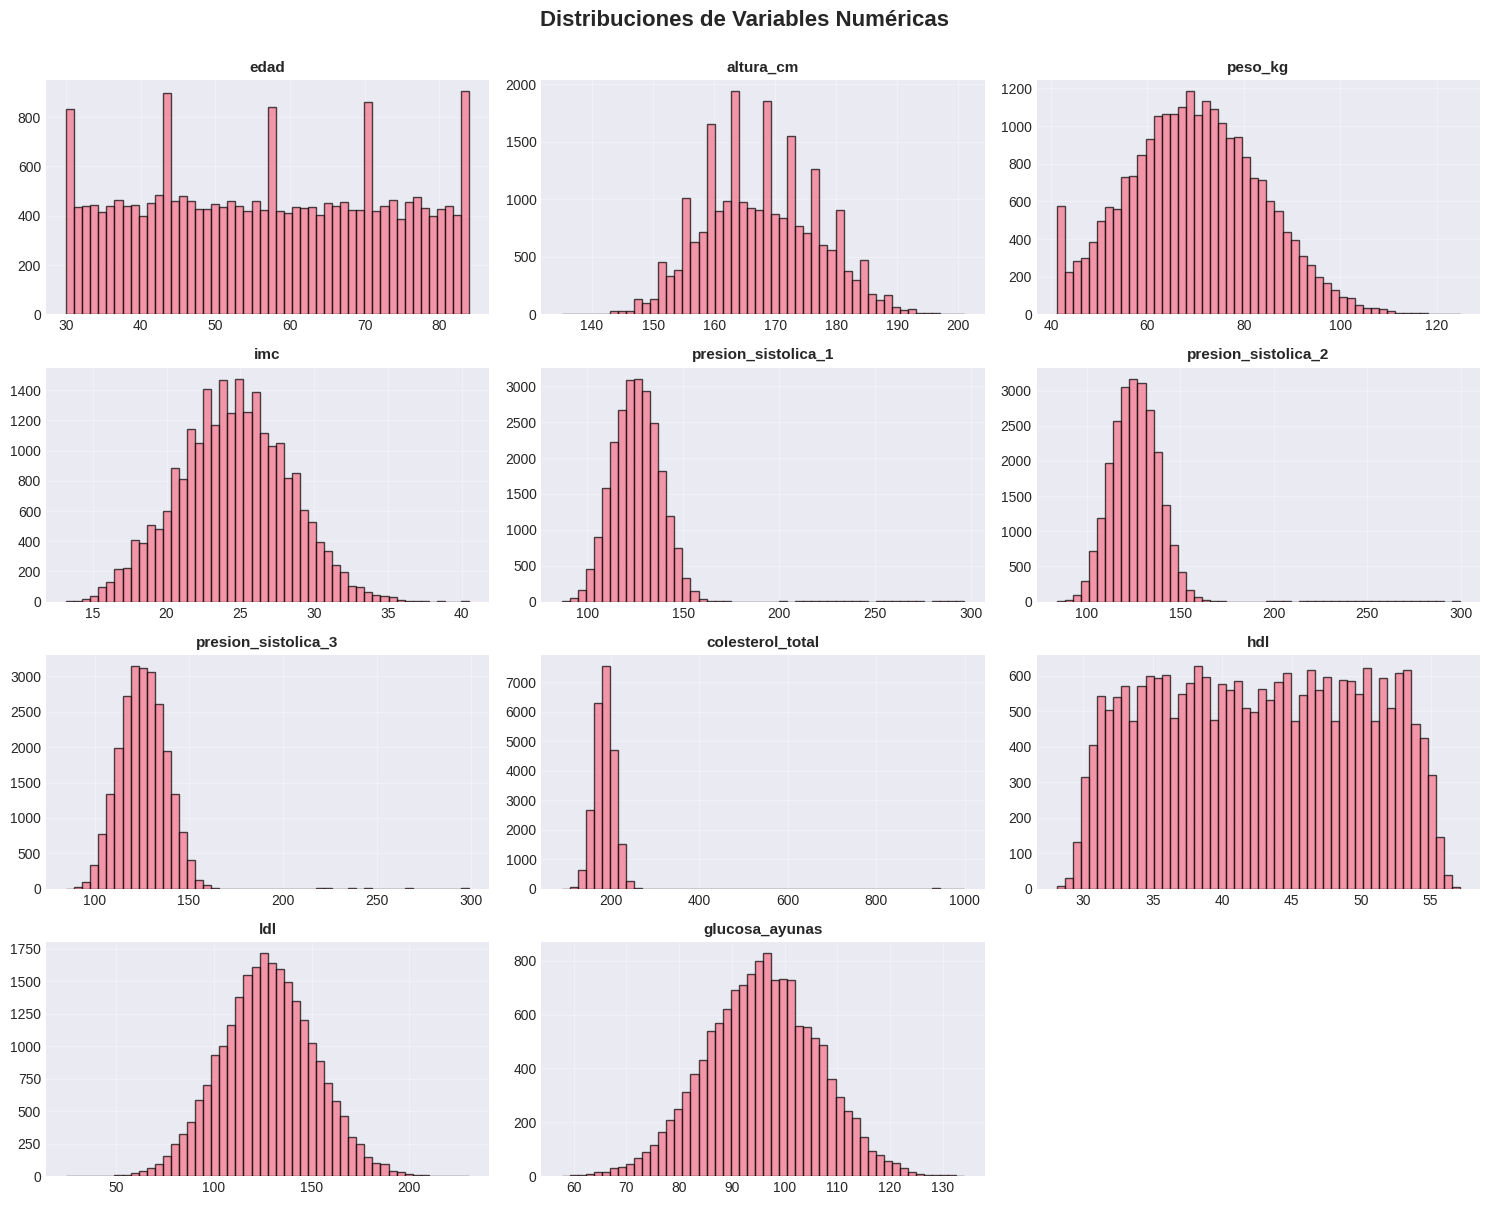

In [30]:
# Visualización de distribuciones
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(vars_numericas_continuas):
    # Histograma con KDE
    cardis_df_train[col].hist(bins=50, ax=axes[idx], alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].grid(alpha=0.3)

# Ocultar el último subplot si sobra
if len(vars_numericas_continuas) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Distribuciones de Variables Numéricas', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

Como podemos ver gracias a estas visualizaciones, no parece que existan una gran cantidad de valores anómalos, por lo que podemos inferir que:
- Si que existen en variables como las presiones sistólicas, el colesterol o el IMC, pero muy probablemente correspondan a casos extremos pero reales, que es importante mantener pues son de vital importancia para nuestro sistema.
- Otras variables no parecen presentar valores anómalos, como la edad (que va de 30 a 84 años y solo tiene valores enteros), el peso (de 40 a 125 kilos, aproximadamente), o la glucosa (entre 60 y 130).

En resumen, estos datos parecen clínicamente posibles, incluso con la presencia de casos extremos, y coinciden con los de pacientes que tendría sentido que acudiesen a atención primaria.

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 2. Distribución del target y desbalanceo

Una vez analizadas las variables con las que vamos a trabajar, es igual de importante analizar la variable objetivo, para ver si está balanceada, y de qué tipo es.

=== DISTRIBUCIÓN DE RIESGO_CV ===
riesgo_cv
0    18744
1     5256
Name: count, dtype: int64

Porcentajes:
riesgo_cv
0    78.1
1    21.9
Name: proportion, dtype: float64


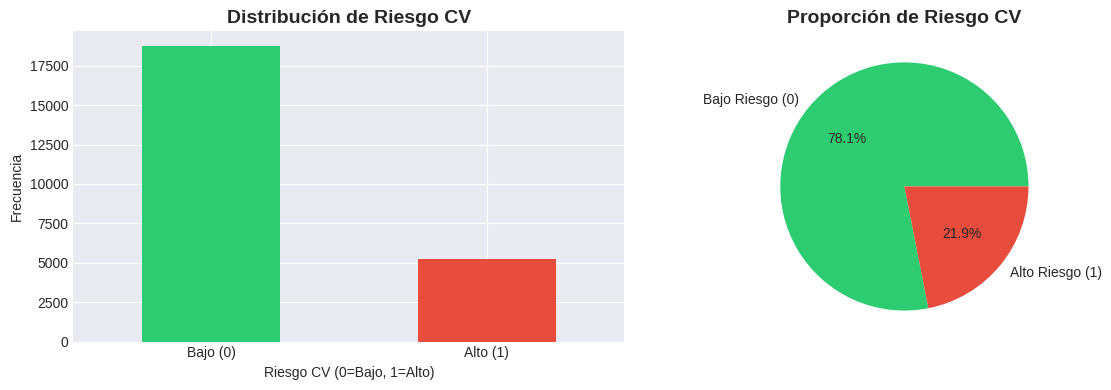

Ratio de desbalance: 3.57:1
Las clases están DESBALANCEADAS. Considerar técnicas de balanceo o usar métricas apropiadas (F1-Score).


In [33]:
# Distribución de la variable objetivo
print("=== DISTRIBUCIÓN DE RIESGO_CV ===")
print(cardis_df_train['riesgo_cv'].value_counts())
print("\nPorcentajes:")
print(cardis_df_train['riesgo_cv'].value_counts(normalize=True) * 100) # Con normalize, podemos ver porcentajes

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
cardis_df_train['riesgo_cv'].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Distribución de Riesgo CV', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Riesgo CV (0=Bajo, 1=Alto)')
ax[0].set_ylabel('Frecuencia')
ax[0].set_xticklabels(['Bajo (0)', 'Alto (1)'], rotation=0)

# Gráfico de pie
cardis_df_train['riesgo_cv'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%', 
                                           colors=['#2ecc71', '#e74c3c'],
                                           labels=['Bajo Riesgo (0)', 'Alto Riesgo (1)'])
ax[1].set_title('Proporción de Riesgo CV', fontsize=14, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Calcular desbalance
counts = cardis_df_train['riesgo_cv'].value_counts()
ratio = counts.max() / counts.min()
print(f"Ratio de desbalance: {ratio:.2f}:1")
if ratio > 1.5:
    print("Las clases están DESBALANCEADAS. Considerar técnicas de balanceo o usar métricas apropiadas (F1-Score).")
else:
    print("Las clases están relativamente BALANCEADAS.")

Como podemos ver, la variable objetivo está notablemente desbalanceada. Esto tiene sentido en nuestro contexto, pues este efecto es clínicamente realista, ya que los pacientes, a rasgos generales, son más propensos a no tener un alto riesgo de sufrir una enfermedad cardiovascular que a tenerlo.

Sin embargo, no debemos pasar esto por alto, ya que podríamos obtener modelos con una alta _accuracy_ pero un _recall_ bajo, y eso significaría que tenemos un modelo que se "arriesga" poco, dando lugar a muchos falsos negativos, lo que es un problema en modelos clínicos. Por ello, es importante saber que métricas utilizar, como es el F1-Score en este caso como métrica principal; o la validación estratificada.

De la misma manera, el desbalanceo de estas clases también tiene implicaciones sobre la equidad, pues, si hay grupos infrarrepresentados en este conjunto de datos, este problema se amplifica de forma rápida.

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 3. Valores ausentes: análisis y estrategia

Como se ha mencionado en apartados anteriores, existen variables que tienen valores ausentes. A continuación, se mostrarán estas variables y se indicará como se pueden resolver estas incongruencias en función de su carácter.

=== VALORES FALTANTES EN TRAIN ===
      Variable  Missing_Count  Missing_Pct
glucosa_ayunas          10394    43.308333
 notas_medicas           4833    20.137500
       fumador           2218     9.241667

Total de variables con missing: 3


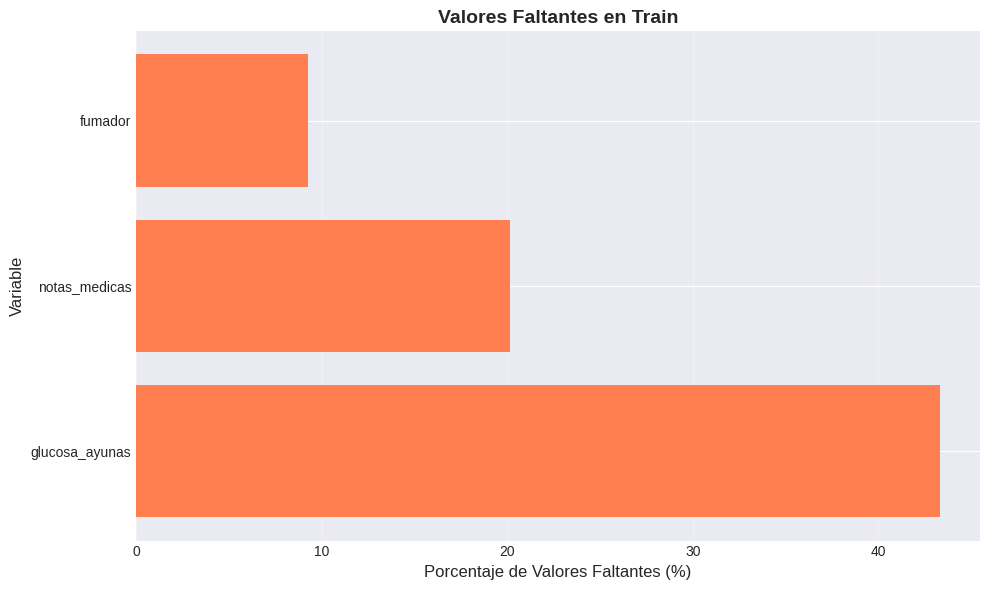

In [36]:
# Análisis de valores faltantes
def analizar_missing(df, nombre="Dataset"):
    """
    Analiza y visualiza los valores faltantes en un DataFrame.
    """
    print(f"=== VALORES FALTANTES EN {nombre.upper()} ===")
    
    # Calcular missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    # Crear DataFrame con resultados
    missing_df = pd.DataFrame({
        'Variable': missing.index,
        'Missing_Count': missing.values,
        'Missing_Pct': missing_pct.values
    })
    
    # Filtrar solo las que tienen missing
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
    
    if len(missing_df) == 0:
        print("✅ No hay valores faltantes en este dataset.")
        return missing_df
    
    print(missing_df.to_string(index=False))
    print(f"\nTotal de variables con missing: {len(missing_df)}")
    
    # Visualización
    if len(missing_df) > 0:
        plt.figure(figsize=(10, max(6, len(missing_df) * 0.3)))
        plt.barh(missing_df['Variable'], missing_df['Missing_Pct'], color='coral')
        plt.xlabel('Porcentaje de Valores Faltantes (%)', fontsize=12)
        plt.ylabel('Variable', fontsize=12)
        plt.title(f'Valores Faltantes en {nombre}', fontsize=14, fontweight='bold')
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    return missing_df

# Analizar train
missing_train = analizar_missing(cardis_df_train, "Train")

Como se puede ver, tenemos tres columnas con valores faltantes:
- **fumador**: con aproximadamente el 9% de valores perdidos, probablemente por que en muchos casos no se pregunte al paciente si es fumador habitual o no.
- **notas_medicas**: con en torno al 20% de valores perdidos, posiblemente por ausencia de hallazgos clínicos, aunque también podría indicar que no se registró sin motivo aparente.
- **glucosa_ayunas**: con aproximadamente el 45% de valores faltantes, lo que podría indicar que no a todos los pacientes se les hace una análitica, en caso de no ser necesario.

En cuanto a las estrategias que se pueden tomar para imputar estos valores desconocidos, recomendamos imputar por la moda o mediana en todos los casos, pero también evaluar si conviene añadir una categoría extra a las notas médicas que sea _desconocido_.

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 4. Valores atípicos e inconsistencias

Otro punto importante a tratar son los valores atípicos o _outliers_, donde conviene distinguir de la forma más eficaz posible entre errores de medición, o valores extremos que pueden ser plausibles, aunque poco comunes.

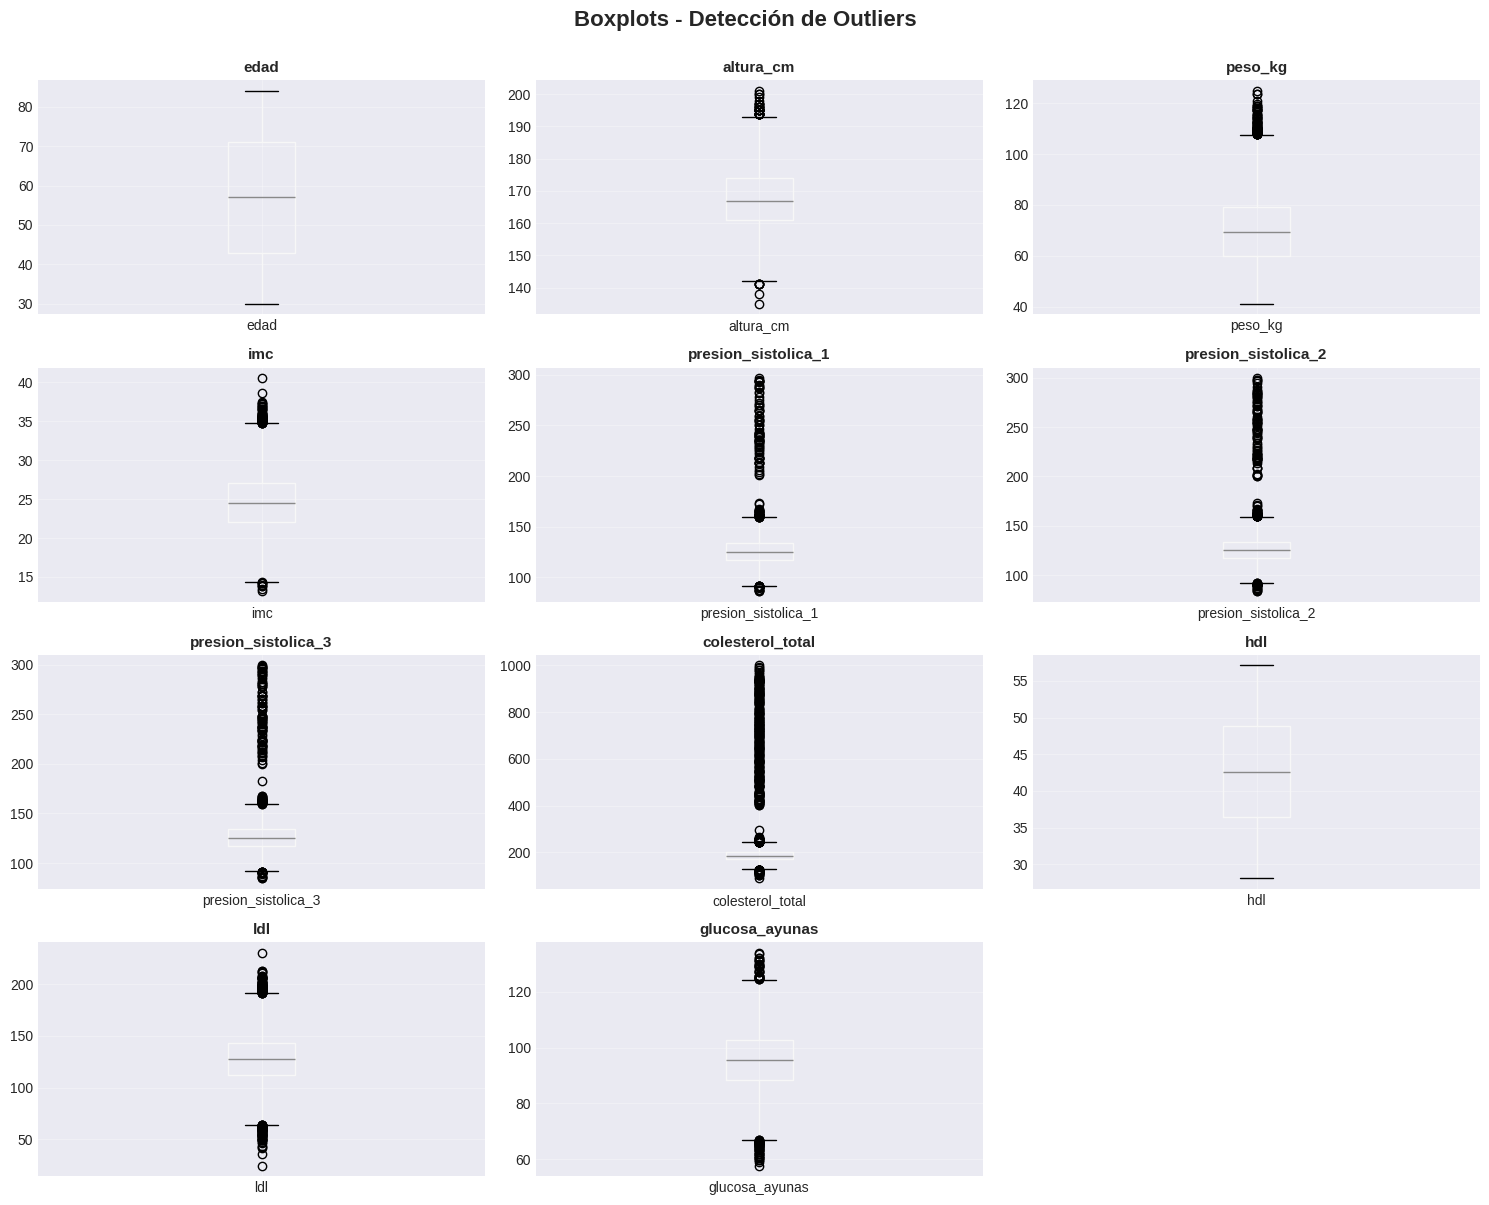

In [37]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(vars_numericas_continuas):
    cardis_df_train.boxplot(column=col, ax=axes[idx])
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('')
    axes[idx].grid(alpha=0.3)

# Ocultar el último subplot si sobra
if len(vars_numericas_continuas) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Boxplots - Detección de Outliers', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

Como podemos ver, además del colesterol HDL y la edad, la mayoría de estas variables tienen _outliers_. Cuantifiquémoslos:

In [39]:
# Análisis cuantitativo de outliers usando IQR
def detectar_outliers_iqr(df, columnas):
    """
    Detecta outliers usando el método del rango intercuartílico (IQR).
    """
    outliers_info = []
    
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        column_min = df[col].min()
        column_max = df[col].max()
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        n_outliers = len(outliers)
        pct_outliers = (n_outliers / len(df)) * 100
        
        outliers_info.append({
            'Variable': col,
            'N_Outliers': n_outliers,
            'Pct_Outliers': pct_outliers,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Min': column_min,
            'Max': column_max
        })
    
    return pd.DataFrame(outliers_info).sort_values('Pct_Outliers', ascending=False)

print("=== OUTLIERS DETECTADOS (Método IQR) ===")
outliers_df = detectar_outliers_iqr(cardis_df_train, vars_numericas_continuas)
print(outliers_df.to_string(index=False))

=== OUTLIERS DETECTADOS (Método IQR) ===
           Variable  N_Outliers  Pct_Outliers  Lower_Bound  Upper_Bound   Min   Max
   colesterol_total         397      1.654167     126.1500     244.9500  89.1 999.8
                ldl         159      0.662500      63.8500     191.4500  24.6 230.5
presion_sistolica_2         157      0.654167      91.7500     159.3500  84.0 299.4
presion_sistolica_3         154      0.641667      91.6000     159.6000  84.7 299.2
presion_sistolica_1         134      0.558333      91.5000     159.5000  86.5 296.6
            peso_kg          87      0.362500      31.5625     107.6625  41.2 124.8
     glucosa_ayunas          84      0.350000      66.9000     124.5000  57.7 134.1
                imc          81      0.337500      14.3500      34.7500  13.2  40.5
          altura_cm          42      0.175000     141.5000     193.5000 135.0 201.0
               edad           0      0.000000       1.0000     113.0000  30.0  84.0
                hdl           0    

De acuerdo a los datos obtenidos, tan solo tenemos com máximo un 1.65% de valores atípicos en una columna, en este caso la de **colesterol_total**. El resto de columnas numéricas apenas llegan al 0.66% de _outliers_. En cuanto a si son errores de medición, es difícil de predecir, pues valores como el máximo de colesterol total en torno a 1000, aunque extremos, pueden ser posibles. En el resto de columnas tampoco se ven valores imposibles, por lo que mantendremos todos estos valores atípicos, pues pueden ser relevantes para el modelo.

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 5. Correlaciones y relaciones

En este paso, analizaremos las correlaciones entre diferentes variables, que nos ayudarán a determinar cuales son aquellas más descriptivas para el modelo.

=== MATRIZ DE CORRELACIONES ===


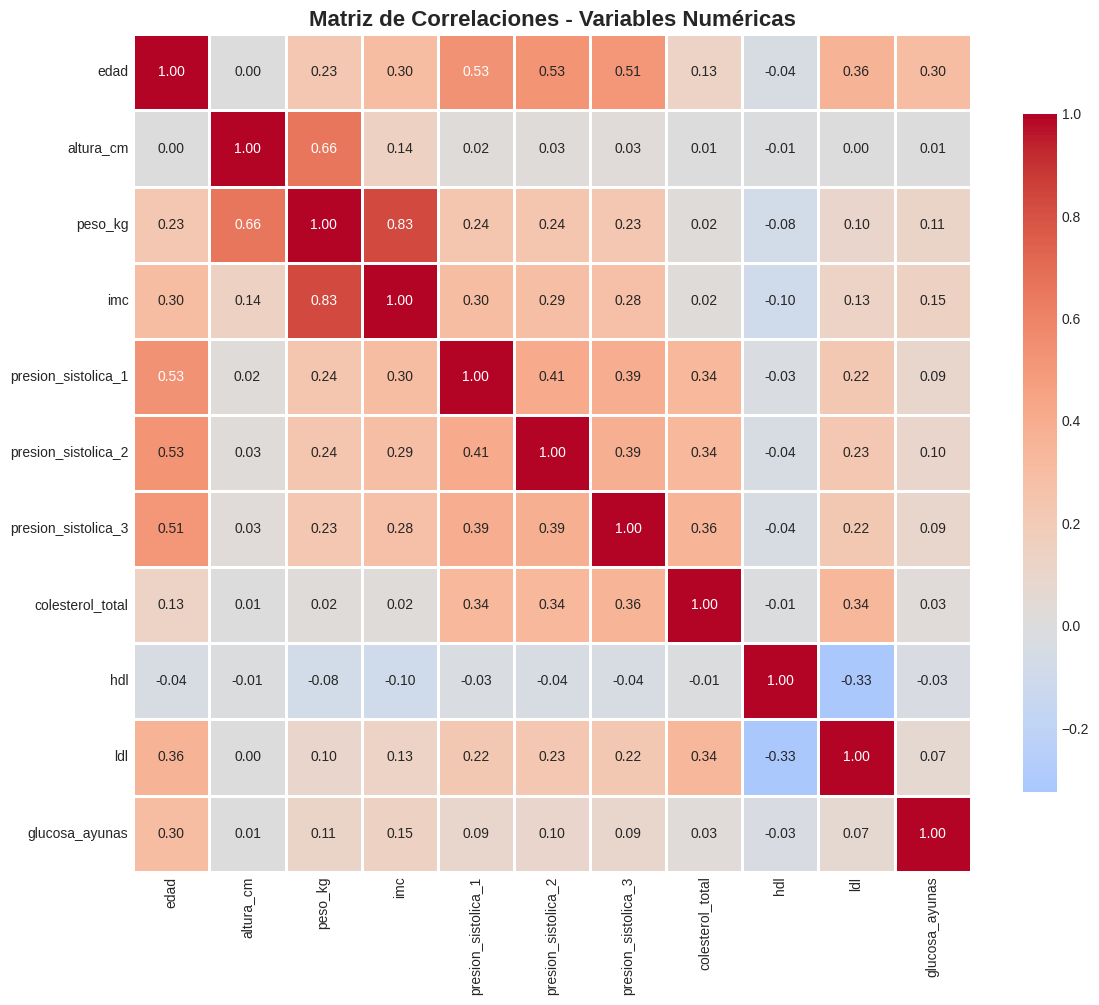


=== CORRELACIONES MÁS FUERTES (|r| > 0.7) ===
Variable_1 Variable_2  Correlación
   peso_kg        imc      0.83059


In [40]:
# Análisis de correlaciones entre variables numéricas
print("=== MATRIZ DE CORRELACIONES ===")

# Calcular correlaciones
correlaciones = cardis_df_train[vars_numericas_continuas].corr()

# Visualización
plt.figure(figsize=(12, 10))
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlaciones - Variables Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Identificar correlaciones altas (excluyendo la diagonal)
print("\n=== CORRELACIONES MÁS FUERTES (|r| > 0.7) ===")
correlaciones_altas = []
for i in range(len(correlaciones.columns)):
    for j in range(i+1, len(correlaciones.columns)):
        if abs(correlaciones.iloc[i, j]) > 0.7:
            correlaciones_altas.append({
                'Variable_1': correlaciones.columns[i],
                'Variable_2': correlaciones.columns[j],
                'Correlación': correlaciones.iloc[i, j]
            })

if correlaciones_altas:
    df_corr_altas = pd.DataFrame(correlaciones_altas).sort_values('Correlación', 
                                                                    key=abs, 
                                                                    ascending=False)
    print(df_corr_altas.to_string(index=False))
else:
    print("No se encontraron correlaciones superiores a 0.7")

Como podemos ver, la correlación más alta entre variables es entre el peso y el IMC, pues tiene sentido que una persona que pesa más, también tenga un IMC más elevado. En este caso, parece que la altura no está tan relacionada con el IMC como podría parecer en primera instancia. Por otra parte, el peso y la altura si parecen relacionadas.

Otras correlaciones a destacar ocurren entre las 3 presiones sistólicas, como cabría esperar; pero tambien entre ellas y la edad, indicando que personas más adultas tendrán una presión más elevada. Esto parece indicar que utilizar 3 mediciones de la presión no resulta útil del todo. En cuanto al colesterol, parece que el HDL y el LDL tienen una correlación inversa, algo que también parece intuitivo a priori.

A continuación, veremos la relación de estas variables con la variable objetivo:

=== CORRELACIONES CON RIESGO_CV ===
edad                   0.412331
ldl                    0.347480
presion_sistolica_2    0.326299
presion_sistolica_1    0.317846
presion_sistolica_3    0.308997
glucosa_ayunas         0.285772
imc                    0.208543
peso_kg                0.163090
colesterol_total       0.129014
altura_cm              0.009358
hdl                   -0.065157
Name: riesgo_cv, dtype: float64


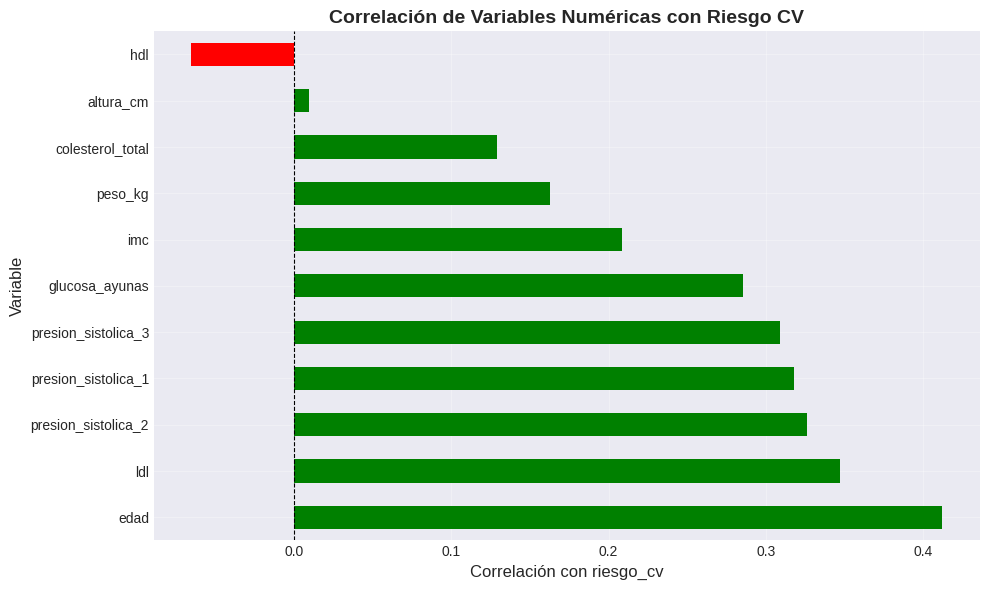


=== INTERPRETACIÓN ===
Correlaciones positivas: Mayor valor de la variable, mayor riesgo CV
Correlaciones negativas: Mayor valor de la variable, menor riesgo CV

Variables con correlación más fuerte (|r| > 0.1):
  - edad: 0.412
  - ldl: 0.347
  - presion_sistolica_2: 0.326
  - presion_sistolica_1: 0.318
  - presion_sistolica_3: 0.309
  - glucosa_ayunas: 0.286
  - imc: 0.209
  - peso_kg: 0.163
  - colesterol_total: 0.129


In [41]:
# Calcular correlaciones con riesgo_cv
print("=== CORRELACIONES CON RIESGO_CV ===")
correlaciones_target = cardis_df_train[vars_numericas_continuas + ['riesgo_cv']].corr()['riesgo_cv'].drop('riesgo_cv').sort_values(ascending=False)
print(correlaciones_target)

# Visualización
plt.figure(figsize=(10, 6))
correlaciones_target.plot(kind='barh', color=['green' if x > 0 else 'red' for x in correlaciones_target])
plt.xlabel('Correlación con riesgo_cv', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.title('Correlación de Variables Numéricas con Riesgo CV', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretación
print("\n=== INTERPRETACIÓN ===")
print("Correlaciones positivas: Mayor valor de la variable, mayor riesgo CV")
print("Correlaciones negativas: Mayor valor de la variable, menor riesgo CV")
print("\nVariables con correlación más fuerte (|r| > 0.1):")
vars_importantes = correlaciones_target[abs(correlaciones_target) > 0.1]
if len(vars_importantes) > 0:
    for var, corr in vars_importantes.items():
        print(f"  - {var}: {corr:.3f}")
else:
    print("  Ninguna variable tiene correlación > 0.1 con el target")

Basándonos en los datos anteriores, podemos afirmar que la edad es el predictor más fuerte ($r=0.41$), seguida del LDL ($r=0.35$) y las tres mediciones de presión sistólica ($r≈0.31-0.33$). La glucosa en ayunas, en cambio, muestra una correlación moderada ($r=0.29$), algo importante dado que tiene 45% de valores faltantes.

El HDL presenta correlación negativa muy débil ($r=-0.07$), menor de lo esperado clínicamente, lo que sugiere que su efecto protector podría manifestarse en interacciones con otras variables. El IMC y peso muestran correlaciones positivas moderadas ($r=0.21$ y $r=0.16$).

Las variables más predictivas de forma univariada son, en este orden: edad, colesterol LDL, presiones sistólicas y glucosa en ayunas.

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 6. Variables de texto libre y categóricas de alta cardinalidad

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 7. Análisis de sesgos poblaciones y equidad

<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555">

## 8. Conclusiones y estrategia propuesta